MACD – I have used 12 period EMA because this is more sensitive and quicker to respond to price changes providing crucial sensitivity for short term price movements. 26 period EMA has been used because it reacts more slowly to price variations and is better for long term trends. I have also used close value for MACD because they incorporate and represent the events of the entire day and the final market sentiment. These prices unlike open prices are not affected by sudden events like overnight news and premarket trading.

Volume RSI – I have used 14 days lookback period because it is more responsive and therefore dependable for general market analysis. Volume values have been used for RSI because they represent the number of shares traded of a particular stock.

Average True Value – I have used 14 days look back period because longer timeframes tend to be slower and give fewer trading signals while shorter timeframes tend to increase trading activity. 14 days on the other hand is a good balance that responds well to volatility changes and helps filter our noise.


No crossover occurs.
0         0.000000
1         0.000000
2        27.132080
3        48.981634
4        68.771210
           ...    
37803    97.391360
37804    88.826992
37805    60.036937
37806    38.328069
37807    35.999718
Name: MACD, Length: 37808, dtype: float64 0         0.000000
1         0.000000
2         5.426416
3        14.137460
4        25.064210
           ...    
37803    91.285963
37804    90.794169
37805    84.642722
37806    75.379792
37807    67.503777
Name: Signal_Line, Length: 37808, dtype: float64
0          0.000000
1          0.000000
2         25.537857
3         26.149439
4         29.076622
            ...    
37803    218.980878
37804    214.682244
37805    236.319226
37806    240.653567
37807    245.864027
Name: ATR, Length: 37808, dtype: float64


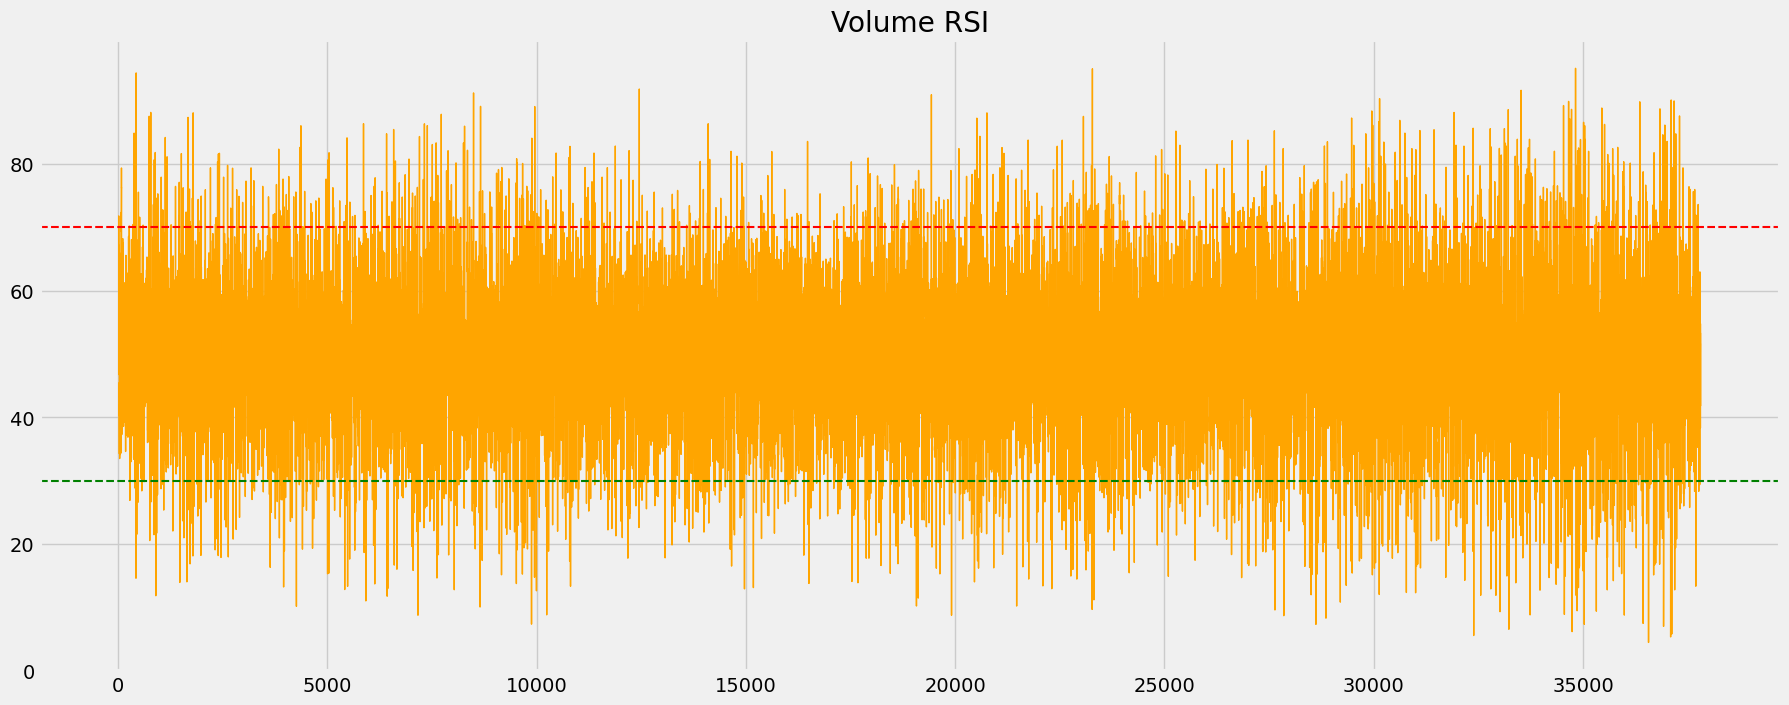

In [3]:
#import the necessary files
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime, timedelta
import yfinance as yf
import os
import csv

#take user input for ticker
data = pd.read_csv('CSV resource.csv')

#Calculate the 12-period EMA
data['EMA12'] = data['close'].ewm(span=12, adjust=False).mean()

# Calculate the 26-period EMA
data['EMA26'] = data['close'].ewm(span=26, adjust=False).mean()

# Calculate MACD (the difference between 12-period EMA and 26-period EMA)
data['MACD'] = data['EMA12'] - data['EMA26']

# Calculate the 9-period EMA of MACD (Signal Line)
data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()

# Check for MACD and Signal Line crossovers in the last two rows
last_row = data.iloc[-1]
second_last_row = data.iloc[-2]

#define output based on various situations of crossing over
if second_last_row['MACD'] > second_last_row['Signal_Line'] and last_row['MACD'] < last_row['Signal_Line']:
    print('The sentiment  is bearish because the MACD line is lesser than the signal line.')
elif second_last_row['MACD'] < second_last_row['Signal_Line'] and last_row['MACD'] > last_row['Signal_Line']:
    print('The sentiment is bullish because the MACD line is greater than the signal line.')
else:
    print('No crossover occurs.')
print(data['MACD'], data['Signal_Line'])

#Volume RSI
change = data["volume"].diff()
change.dropna(inplace=True)

# Create two copies of the Closing price Series
change_up = change.copy()
change_down = change.copy()

# Keep only positive values for change up and negative ones for change down
change_up[change_up<0] = 0
change_down[change_down>0] = 0

# Verify that we did not make any mistakes
change.equals(change_up+change_down)

# Calculate the rolling average of average up and average down
avg_up = change_up.rolling(14).mean()
avg_down = change_down.rolling(14).mean().abs()
rsi = 100 * avg_up / (avg_up + avg_down)
rsi.head(20)

#Set the theme of our chart
plt.style.use('fivethirtyeight')

# Make our resulting figure much bigger
plt.rcParams['figure.figsize'] = (20, 20)
ax1 = plt.subplot2grid((10,1), (5,0), rowspan = 4, colspan = 1)

ax1.set_title('Volume RSI')
ax1.plot(rsi, color='orange', linewidth=1)
# Add two horizontal lines, signalling the buy and sell ranges.
# Oversold
ax1.axhline(30, linestyle='--', linewidth=1.5, color='green')
# Overbought
ax1.axhline(70, linestyle='--', linewidth=1.5, color='red')

#Average True Value
def wwma(values, n):
    return values.ewm(alpha=1/n, adjust=False).mean()

def atr(df, n):
    data = df.copy()
    high = data['high']
    low = data['low']
    close = data['close']
    data['Case 1'] = abs(high - low)
    data['Case 2'] = abs(high - close.shift())
    data['Case 3'] = abs(low - close.shift())
    case = data[['Case 1', 'Case 2', 'Case 3']].max(axis=1)
    df['ATR'] = wwma(case, n)
    return df['ATR']
print(atr(data, 14))